In [1]:
# Import packages and plotting setup
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import string
from pathlib import Path

from Functions import setup_matplotlib_parameter

wong_cycle = setup_matplotlib_parameter()

In [2]:
# Load data
data_dir = Path("..") / "Data files" / "Type distribution"

# Type distribution S1-S3
df_mikro = pd.read_excel(data_dir / "Type distribution.xlsx", sheet_name="S1-S3")

# Type distribution S4-S8
df_sub = pd.read_excel(data_dir / "Type distribution.xlsx", sheet_name="S4-S8")

RENAME = {"Alumina": "Alumina", "spinel": "Spinel",
          "Ca-rich transient (CaO-CaS)": "Ca-rich transient",
          "Mg-bearing Calcium aluminate": "Mg-bearing Ca-aluminate",
          "Mg-poor Calcium aluminate": "Mg-poor Ca-aluminate"}

def prep(df):
    return df.rename(columns=RENAME).copy()

df_all = pd.concat([prep(df_mikro), prep(df_sub)], ignore_index=True)

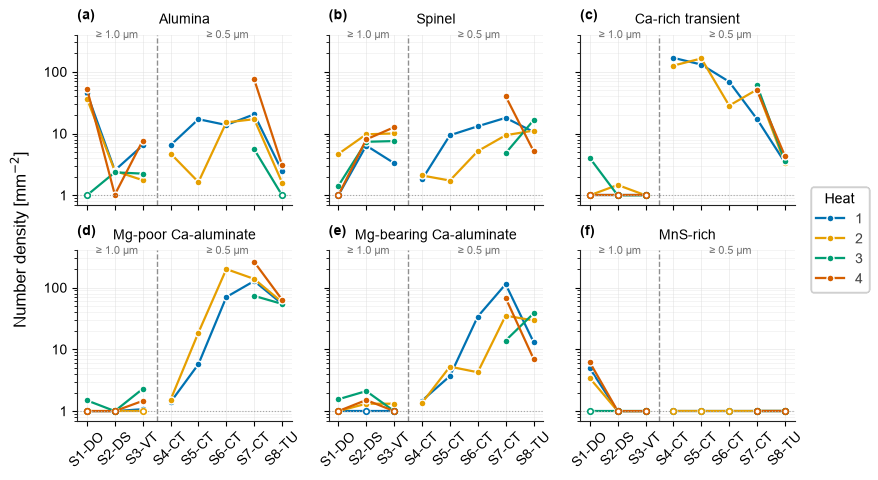

In [3]:
TYPE_COLS = ["Alumina", "Spinel", "Ca-rich transient",
             "Mg-poor Ca-aluminate", "Mg-bearing Ca-aluminate", "MnS-rich"]
STAGES = ["S1-DO","S2-DS","S3-VT","S4-CT","S5-CT","S6-CT","S7-CT","S8-TU"]
FLOOR = 1

long = df_all.melt(id_vars=["Sampling stage","Heat"], value_vars=TYPE_COLS,
               var_name="Type", value_name="density")

long["plot_val"] = long["density"].clip(lower=FLOOR)
long["is_zero"]  = long["density"] <= 1
xpos = {s: i for i, s in enumerate(STAGES)}

heats  = sorted(df_all["Heat"].unique())
colors = {h: wong_cycle[i % len(wong_cycle)] for i, h in enumerate(heats)}

fig, axes = plt.subplots(2, 3, figsize=(210/25.4, 297/25.4*0.42), sharey=True, sharex=True)

legend_handles = []
k=0

for ax, t in zip(axes.ravel(), TYPE_COLS):

    # Add panel description
    ax.text(
        0.0,
        1.15,
        f"({string.ascii_lowercase[k]})",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontweight="bold",
    )
    k += 1

    # Add submicro and micro description
    ax.text(
        0.185,
        .98,
        u"\u2265 1.0 µm",
        transform=ax.transAxes,
        fontsize=8,
        ha="center",
        color="0.45",
    )
    ax.text(
        0.7,
        .98,
        u"\u2265 0.5 µm",
        transform=ax.transAxes,
        fontsize=8,
        ha="center",
        color="0.45",
    )

    d = long[long["Type"] == t]
    for i, (h, g) in enumerate(d.groupby("Heat")):
        # g = g.assign(xp=g["Sampling stage"].map(xpos)).sort_values("xp")
        g = g.assign(xp=g["Sampling stage"].map(xpos)).sort_values("xp")

        left = g[g["xp"] <= 2]
        right = g[g["xp"] >= 3]

        for part in [left, right]:

            if len(part) == 0:
                continue

            gaps = np.where(np.diff(part["xp"]) > 1)[0]

            if len(gaps) == 0:
                line, = ax.plot(
                    part["xp"], part["plot_val"],
                    marker="o",
                    markersize=5,
                    linewidth=1.6,
                    mec="white",
                    color=wong_cycle[i],
                    label=f"{h}",
                )

            else:
                start = 0
                for gap in gaps:
                    seg = part.iloc[start:gap+1]
                    ax.plot(
                        seg["xp"], seg["plot_val"],
                        marker="o",
                        markersize=5,
                        linewidth=1.6,
                        mec="white",
                        color=wong_cycle[i],
                        label=f"{h}" if start == 0 else None,
                    )

                    p1 = part.iloc[gap]
                    p2 = part.iloc[gap + 1]

                    ax.plot(
                        [p1["xp"], p2["xp"]],
                        [p1["plot_val"], p2["plot_val"]],
                        ls="--",
                        lw=1.6,
                        color=wong_cycle[i],
                    )

                    start = gap + 1

                seg = part.iloc[start:]
                ax.plot(
                    seg["xp"], seg["plot_val"],
                    marker="o",
                    markersize=5,
                    linewidth=1.6,
                    mec="white",
                    color=wong_cycle[i],
                )

                if t == TYPE_COLS[0]:
                    legend_handles.append(line)

        # Zero markers
        z = g[g["is_zero"] == True]                      # zeros: open markers at the floor
        ax.plot(z["xp"], z["plot_val"], marker="o", ms=4, ls="none",
                mfc="white", mec=wong_cycle[i], mew=1.2, zorder=5)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Detection limit line
    ax.axvline(
        2.5,
        color="0.45",
        lw=1,
        ls="--",
        alpha=0.8,
    )

    # Floor line
    ax.axhline(FLOOR, color="0.65", lw=0.8, ls=":")

    ax.set_yscale("log")
    ax.set_title(t, pad=8, fontweight="normal")
    ax.set_ylim((0.7, 400))
    ax.set_yticks([1, 10, 100])
    ax.set_yticklabels(["1", "10", "100"])

    ax.set_xticks(range(len(STAGES)))
    ax.set_xticklabels(STAGES, rotation=45)
    ax.grid(True, which="major", color="0.88", lw=0.7)
    ax.grid(True, which="minor", color="0.88", lw=0.5)

    handles, labels = axes[0, 0].get_legend_handles_labels()

    by_label = dict(zip(labels, handles))

    fig.legend(
        by_label.values(),
        by_label.keys(),
        title="Heat",
        loc="center left",
        bbox_to_anchor=(0.98, 0.5),
        frameon=True,
    )

fig.supylabel("Number density [mm$^{-2}$]", fontsize=12)

# Leave room for legend
fig.tight_layout()